In [11]:
pip install requests pandas matplotlib seaborn wordcloud vaderSentiment googletrans==4.0.0-rc1

  Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl.metadata (572 bytes)
  Using cached googletrans-4.0.0rc1-py3-none-any.whl
  Using cached httpx-0.13.3-py3-none-any.whl.metadata (25 kB)
  Using cached hstspreload-2025.1.1-py3-none-any.whl.metadata (2.1 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached chardet-3.0.4-py2.py3-none-any.whl.metadata (3.2 kB)
  Using cached idna-2.10-py2.py3-none-any.whl.metadata (9.1 kB)
  Using cached rfc3986-1.5.0-py2.py3-none-any.whl.metadata (6.5 kB)
  Using cached httpcore-0.9.1-py3-none-any.whl.metadata (4.6 kB)
  Using cached h11-0.9.0-py2.py3-none-any.whl.metadata (8.1 kB)
  Using cached h2-3.2.0-py2.py3-none-any.whl.metadata (32 kB)
  Using cached hyperframe-5.2.0-py2.py3-none-any.whl.metadata (7.2 kB)
  Using cached hpack-3.0.0-py2.py3-none-any.whl.metadata (7.0 kB)
Using cached httpx-0.13.3-py3-none-any.whl (55 kB)
Using cached chardet-3.0.4-py2.py3-none-any.whl (133 kB)
Using cached httpcore-0.9.1-py3-none


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: C:\Users\55119\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import os

# Define o caminho para o nosso arquivo de dados JÁ PROCESSADO
filepath = '../data/ml_reviews_processed.csv'

# --- Bloco de Carregamento Seguro ---
try:
    # Tenta carregar o DataFrame a partir do arquivo
    df = pd.read_csv(filepath)

    # Se o carregamento for bem-sucedido, imprime uma confirmação e informações
    print("DataFrame processado carregado com sucesso!")
    print("-" * 40)
    print("Informações do DataFrame:")
    df.info() # .info() é ótimo para ver colunas, contagem de nulos e tipos de dados

    print("\nAs 5 primeiras linhas:")
    display(df.head()) # 'display()' funciona melhor que 'print()' para DataFrames em notebooks

except FileNotFoundError:
    # Se o arquivo não for encontrado, imprime uma mensagem de erro clara
    print(f"ERRO: O arquivo '{filepath}' não foi encontrado.")
    print("Por favor, execute o notebook anterior (02-text-preprocessing.ipynb) para gerar o arquivo processado.")
    df = None # Define df como None para evitar erros nas células seguintes

except Exception as e:
    # Pega qualquer outro erro que possa ocorrer durante o carregamento
    print(f"Ocorreu um erro inesperado ao carregar o arquivo: {e}")
    df = None

DataFrame processado carregado com sucesso!
----------------------------------------
Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   title       0 non-null      float64
 1   text        9 non-null      object 
 2   date        9 non-null      object 
 3   text_clean  9 non-null      object 
dtypes: float64(1), object(3)
memory usage: 420.0+ bytes

As 5 primeiras linhas:


,title,text,date,text_clean
0,NaN,Produto √© bonito e rapido tanto para ligar ou...,16 mar. 2025,produto bonito rapido tanto ligar reiniciar bo...
1,NaN,Estou adorando üòä.,14 mar. 2025,adorando
2,NaN,Aparelho √© sensacional!!!.\nA mem√≥ria √© coi...,17 mar. 2025,aparelho sensacional memria coisa doido super ...
3,NaN,"Aparelho √≥timo, bate de frente com aparelhos ...",09 mai. 2025,aparelho timo bate frente aparelhos dobro preo...
4,NaN,"Poco x7 pro aparelho espetacular, comprem sem ...",06 mai. 2025,poco x pro aparelho espetacular comprem medo r...


C:\Users\55119\AppData\Local\Temp\ipykernel_2572\1984195647.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequência', y='Palavra', data=df_most_common, palette='viridis')


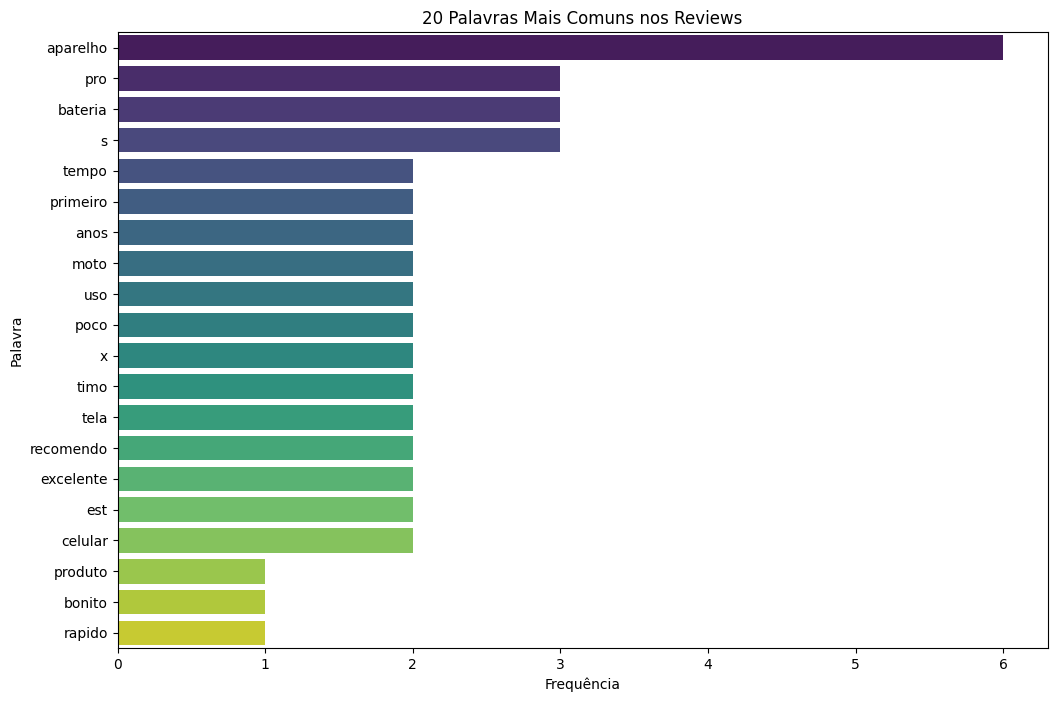

In [3]:
# Importações necessárias para esta fase
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

# Supondo que seu DataFrame 'df' já esteja carregado e com a coluna 'text_clean'
# Se não estiver, carregue o CSV que você salvou no final da fase 2.

# 1. Junte todos os reviews limpos em um único texto
all_text = ' '.join(df['text_clean'])

# 2. Quebre o texto em uma lista de palavras
all_words = all_text.split()

# 3. Conte a frequência de cada palavra
word_counts = Counter(all_words)

# 4. Pegue as 20 palavras mais comuns
most_common_words = word_counts.most_common(20)

# 5. Crie um DataFrame com essas palavras para facilitar a plotagem
df_most_common = pd.DataFrame(most_common_words, columns=['Palavra', 'Frequência'])

# 6. Crie o gráfico de barras
plt.figure(figsize=(12, 8))
sns.barplot(x='Frequência', y='Palavra', data=df_most_common, palette='viridis')
plt.title('20 Palavras Mais Comuns nos Reviews')
plt.xlabel('Frequência')
plt.ylabel('Palavra')
plt.show()

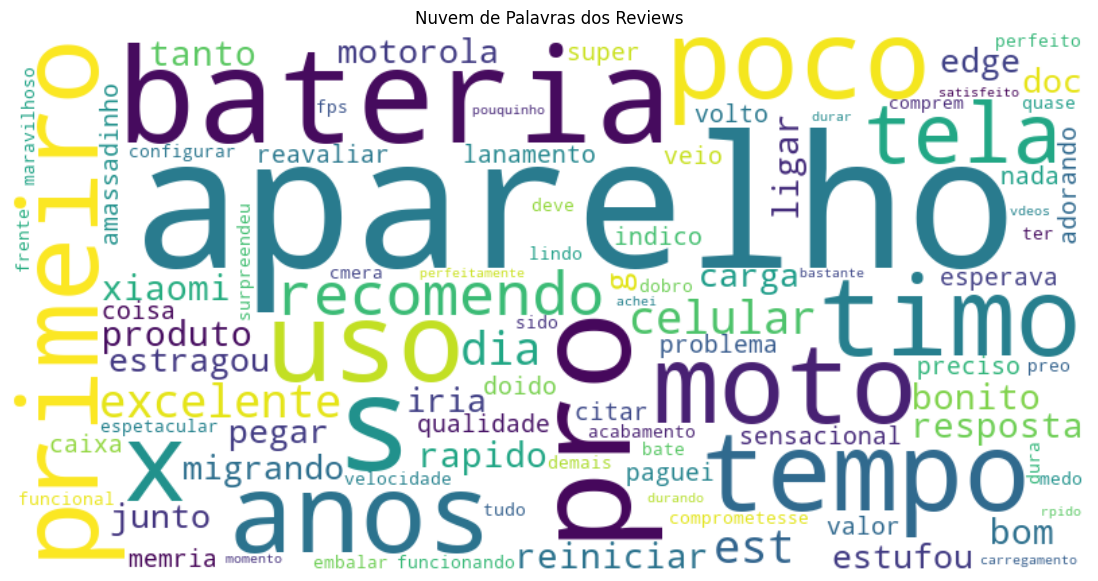

In [4]:
from wordcloud import WordCloud

# Use o mesmo texto gigante 'all_text' que criamos antes

# Crie o objeto WordCloud
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    colormap='viridis',
    max_words=100, # Mostra no máximo 100 palavras
    contour_width=3,
    contour_color='steelblue'
).generate(all_text)

# Plote a imagem da nuvem de palavras
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Remove os eixos x e y
plt.title('Nuvem de Palavras dos Reviews')
plt.show()

In [5]:
from nltk.collocations import BigramAssocMeasures, BigramCollocationFinder

# Crie o buscador de bigramas a partir da nossa lista de todas as palavras
finder = BigramCollocationFinder.from_words(all_words)

# Pegue os 20 bigramas mais frequentes
bigram_measures = BigramAssocMeasures()
top_bigrams = finder.nbest(bigram_measures.pmi, 20) # Você pode usar .pmi ou .raw_freq

print("Os 20 pares de palavras (bigramas) mais comuns são:")
# Imprime os bigramas formatados
for bigram in top_bigrams:
    print(f"- {' '.join(bigram)}")

Os 20 pares de palavras (bigramas) mais comuns são:
- acabamento velocidade
- achei durar
- amassadinho nada
- aparelhos dobro
- bastante satisfeito
- bate frente
- bonito rapido
- caixa veio
- carregamento vdeos
- citar caixa
- coisa doido
- comprem medo
- demais perfeito
- deve ter
- dia achei
- dobro preo
- doc carga
- doido super
- dura quase
- durar pouquinho


In [12]:
# Importações necessárias
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from googletrans import Translator

# Supondo que 'df' já está carregado e pronto
# df = pd.read_csv('../data/ml_reviews_processed.csv') # Se precisar carregar novamente

# 1. Inicializa as ferramentas
analyzer = SentimentIntensityAnalyzer()
translator = Translator()

# 2. Cria a função para obter o sentimento
def get_sentiment_scores(text_portuguese):
    """
    Traduz um texto para o inglês e retorna os scores de sentimento do VADER.
    """
    try:
        # Traduz o texto para inglês
        text_english = translator.translate(text_portuguese, src='pt', dest='en').text
        
        # Calcula os scores de sentimento
        sentiment_scores = analyzer.polarity_scores(text_english)
        return sentiment_scores
        
    except Exception as e:
        # Lida com possíveis erros de tradução
        # print(f"Erro ao traduzir o texto: {text_portuguese}\nErro: {e}")
        return {'neg': 0.0, 'neu': 0.0, 'pos': 0.0, 'compound': 0.0} # Retorna neutro em caso de erro

# 3. Aplica a função na nossa coluna de texto limpo
# Isso pode levar alguns minutos dependendo do número de reviews, pois faz uma chamada de API para cada um.
df['sentiment_scores'] = df['text_clean'].apply(get_sentiment_scores)

# 4. "Desempacota" o dicionário de scores em colunas separadas para facilitar o uso
df = pd.concat([df.drop(['sentiment_scores'], axis=1), df['sentiment_scores'].apply(pd.Series)], axis=1)

print("Scores de sentimento calculados:")
display(df[['text_clean', 'neg', 'neu', 'pos', 'compound']].head())

Scores de sentimento calculados:


,text_clean,neg,neu,pos,compound
0,produto bonito rapido tanto ligar reiniciar bo...,0.089,0.783,0.128,0.4215
1,adorando,0.000,0.000,1.000,0.5994
2,aparelho sensacional memria coisa doido super ...,0.099,0.741,0.160,0.3612
3,aparelho timo bate frente aparelhos dobro preo...,0.000,0.801,0.199,0.4995
4,poco x pro aparelho espetacular comprem medo r...,0.252,0.551,0.197,-0.1779


In [13]:
def classify_sentiment(compound_score):
    """
    Classifica o sentimento em 'Positivo', 'Neutro' ou 'Negativo'
    com base no score 'compound'.
    """
    if compound_score >= 0.05:
        return 'Positivo'
    elif compound_score <= -0.05:
        return 'Negativo'
    else:
        return 'Neutro'

# Aplica a função de classificação para criar a coluna final 'sentiment'
df['sentiment'] = df['compound'].apply(classify_sentiment)

# Salva o DataFrame final, agora com a análise de sentimento completa
df.to_csv('../data/ml_reviews_final.csv', index=False, encoding='utf-8-sig')


print("\nDataFrame final com a classificação de sentimento:")
display(df[['text_clean', 'compound', 'sentiment']].head())

# Mostra a contagem de cada sentimento
print("\nDistribuição dos sentimentos:")
print(df['sentiment'].value_counts())


DataFrame final com a classificação de sentimento:


,text_clean,compound,sentiment
0,produto bonito rapido tanto ligar reiniciar bo...,0.4215,Positivo
1,adorando,0.5994,Positivo
2,aparelho sensacional memria coisa doido super ...,0.3612,Positivo
3,aparelho timo bate frente aparelhos dobro preo...,0.4995,Positivo
4,poco x pro aparelho espetacular comprem medo r...,-0.1779,Negativo



Distribuição dos sentimentos:
sentiment
Positivo    7
Negativo    1
Neutro      1
Name: count, dtype: int64
